In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
import os
import time
import warnings
import numpy as np
import pandas as pd

from pathlib import Path

warnings.filterwarnings("ignore")

In [11]:
DATASET_PATH = "/content/drive/My Drive/Colab Notebooks/Data Sets/Cyber"

In [12]:
OUTPUT_PATH = "/content/drive/My Drive/Colab Notebooks/Data Sets/Cyber/results"

folders = [
    "cleaned_data",
    "logs",
    "tables",
    "figures",
    "models"
]

for folder in folders:
    os.makedirs(os.path.join(OUTPUT_PATH, folder), exist_ok=True)

In [13]:
files = sorted(os.listdir(DATASET_PATH))

print("Files Found:\n")

for file in files:
    print(file)

Files Found:

DNS-testing.parquet
LDAP-testing.parquet
LDAP-training.parquet
MSSQL-testing.parquet
MSSQL-training.parquet
NetBIOS-testing.parquet
NetBIOS-training.parquet
Syn-testing.parquet
Syn-training.parquet
UDP-testing.parquet
UDP-training.parquet
UDPLag-testing.parquet
UDPLag-training.parquet
results


In [14]:
training_files = []
testing_files = []

for file in files:

    if "training" in file.lower():

        training_files.append(file)

    elif "testing" in file.lower():

        testing_files.append(file)

print("Training Files:", len(training_files))
print("Testing Files :", len(testing_files))

Training Files: 6
Testing Files : 7


In [15]:
train_data = {}

for file in training_files:

    attack_name = file.replace("-training.parquet", "")

    path = os.path.join(DATASET_PATH, file)

    df = pd.read_parquet(path)

    train_data[attack_name] = df

print("Training datasets loaded:", len(train_data))

Training datasets loaded: 6


In [16]:
test_data = {}

for file in testing_files:

    attack_name = file.replace("-testing.parquet", "")

    path = os.path.join(DATASET_PATH, file)

    df = pd.read_parquet(path)

    test_data[attack_name] = df

print("Testing datasets loaded:", len(test_data))

Testing datasets loaded: 7


In [17]:
summary = []

for attack in train_data:

    train_rows = train_data[attack].shape[0]

    test_rows = test_data.get(attack, pd.DataFrame()).shape[0]

    summary.append([attack, train_rows, test_rows])

summary_df = pd.DataFrame(
    summary,
    columns=[
        "Attack",
        "Training Rows",
        "Testing Rows"
    ]
)

summary_df

,Attack,Training Rows,Testing Rows
0,LDAP,6715,2831
1,MSSQL,10974,8083
2,NetBIOS,1631,2225
3,Syn,70336,907
4,UDP,17770,12462
5,UDPLag,12639,12465


In [18]:
def clean_dataset(df):

    original_rows = len(df)

    df = df.replace([np.inf, -np.inf], np.nan)

    missing_before = df.isna().sum().sum()

    df = df.dropna()

    duplicates_before = df.duplicated().sum()

    df = df.drop_duplicates()

    final_rows = len(df)

    return (
        df,
        {
            "Original Rows": original_rows,
            "Missing Values Removed": int(missing_before),
            "Duplicate Rows Removed": int(duplicates_before),
            "Final Rows": final_rows
        }
    )

In [19]:
clean_logs = []

for attack in train_data:

    train_data[attack], log = clean_dataset(train_data[attack])

    log["Dataset"] = attack + "_training"

    clean_logs.append(log)

for attack in test_data:

    test_data[attack], log = clean_dataset(test_data[attack])

    log["Dataset"] = attack + "_testing"

    clean_logs.append(log)

In [20]:
clean_log = pd.DataFrame(clean_logs)

clean_log.to_csv(
    os.path.join(
        OUTPUT_PATH,
        "logs",
        "cleaning_log.csv"
    ),
    index=False
)

clean_log.head(6)

,Original Rows,Missing Values Removed,Duplicate Rows Removed,Final Rows,Dataset
0,6715,0,0,6715,LDAP_training
1,10974,0,0,10974,MSSQL_training
2,1631,0,0,1631,NetBIOS_training
3,70336,0,0,70336,Syn_training
4,17770,0,0,17770,UDP_training
5,12639,0,0,12639,UDPLag_training


In [21]:
for attack, df in train_data.items():

    df.to_parquet(
        os.path.join(
            OUTPUT_PATH,
            "cleaned_data",
            f"{attack}_training_clean.parquet"
        )
    )

for attack, df in test_data.items():

    df.to_parquet(
        os.path.join(
            OUTPUT_PATH,
            "cleaned_data",
            f"{attack}_testing_clean.parquet"
        )
    )

In [22]:
example_attack = list(train_data.keys())[0]

print("Example Dataset:", example_attack)

print("\nShape:", train_data[example_attack].shape)

print("\nColumns:")

for col in train_data[example_attack].columns:
    print(col)

Example Dataset: LDAP

Shape: (6715, 78)

Columns:
Protocol
Flow Duration
Total Fwd Packets
Total Backward Packets
Fwd Packets Length Total
Bwd Packets Length Total
Fwd Packet Length Max
Fwd Packet Length Min
Fwd Packet Length Mean
Fwd Packet Length Std
Bwd Packet Length Max
Bwd Packet Length Min
Bwd Packet Length Mean
Bwd Packet Length Std
Flow Bytes/s
Flow Packets/s
Flow IAT Mean
Flow IAT Std
Flow IAT Max
Flow IAT Min
Fwd IAT Total
Fwd IAT Mean
Fwd IAT Std
Fwd IAT Max
Fwd IAT Min
Bwd IAT Total
Bwd IAT Mean
Bwd IAT Std
Bwd IAT Max
Bwd IAT Min
Fwd PSH Flags
Bwd PSH Flags
Fwd URG Flags
Bwd URG Flags
Fwd Header Length
Bwd Header Length
Fwd Packets/s
Bwd Packets/s
Packet Length Min
Packet Length Max
Packet Length Mean
Packet Length Std
Packet Length Variance
FIN Flag Count
SYN Flag Count
RST Flag Count
PSH Flag Count
ACK Flag Count
URG Flag Count
CWE Flag Count
ECE Flag Count
Down/Up Ratio
Avg Packet Size
Avg Fwd Segment Size
Avg Bwd Segment Size
Fwd Avg Bytes/Bulk
Fwd Avg Packets/Bulk
Fw

**RQ1**

In [23]:
import os
import time
import joblib
import psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from lightgbm import LGBMClassifier

In [24]:
DATA_PATH="/content/drive/My Drive/Colab Notebooks/Data Sets/Cyber/results/cleaned_data"

RESULT_PATH="/content/drive/My Drive/Colab Notebooks/Data Sets/Cyber/results"

MODEL_PATH=os.path.join(RESULT_PATH,"models")

TABLE_PATH=os.path.join(RESULT_PATH,"tables")

FIGURE_PATH=os.path.join(RESULT_PATH,"figures")

In [25]:
import os
import pandas as pd

DATA_PATH = "/content/drive/My Drive/Colab Notebooks/Data Sets/Cyber"

train_dfs = []
test_dfs = []

# DNS is reserved for RQ3
EXCLUDED_ATTACK = "DNS"

for file in sorted(os.listdir(DATA_PATH)):

    if not file.endswith(".parquet"):
        continue

    if EXCLUDED_ATTACK.lower() in file.lower():
        continue

    path = os.path.join(DATA_PATH, file)

    df = pd.read_parquet(path)

    print(f"{file} -> {df.shape}")

    if "training" in file.lower():
        train_dfs.append(df)

    elif "testing" in file.lower():
        test_dfs.append(df)

train_df = pd.concat(train_dfs, ignore_index=True)
test_df = pd.concat(test_dfs, ignore_index=True)

print("\nTraining Shape:", train_df.shape)
print("Testing Shape :", test_df.shape)

LDAP-testing.parquet -> (2831, 78)
LDAP-training.parquet -> (6715, 78)
MSSQL-testing.parquet -> (8083, 78)
MSSQL-training.parquet -> (10974, 78)
NetBIOS-testing.parquet -> (2225, 78)
NetBIOS-training.parquet -> (1631, 78)
Syn-testing.parquet -> (907, 78)
Syn-training.parquet -> (70336, 78)
UDP-testing.parquet -> (12462, 78)
UDP-training.parquet -> (17770, 78)
UDPLag-testing.parquet -> (12465, 78)
UDPLag-training.parquet -> (12639, 78)

Training Shape: (120065, 78)
Testing Shape : (38973, 78)


In [26]:
print(train_df.columns.tolist())

['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total', 'Bwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Down/Up Ra

In [27]:
label_mapping = {
    "UDP": "DrDoS_UDP",
    "LDAP": "DrDoS_LDAP",
    "MSSQL": "DrDoS_MSSQL",
    "NetBIOS": "DrDoS_NetBIOS",
    "UDPLag": "UDP-lag"
}

train_df["Label"] = train_df["Label"].replace(label_mapping)
test_df["Label"] = test_df["Label"].replace(label_mapping)

In [28]:
print("Training Labels")
print(train_df["Label"].value_counts())

print()

print("\nTesting Labels")
print(test_df["Label"].value_counts())

Training Labels
Label
Syn              48840
Benign           42007
DrDoS_UDP        18090
DrDoS_MSSQL       8523
DrDoS_LDAP        1906
DrDoS_NetBIOS      644
UDP-lag             55
Name: count, dtype: int64


Testing Labels
Label
Benign           10847
DrDoS_UDP        10420
UDP-lag           8872
DrDoS_MSSQL       6212
DrDoS_LDAP        1440
DrDoS_NetBIOS      598
Syn                533
WebDDoS             51
Name: count, dtype: int64


In [29]:
test_df = test_df[
    test_df["Label"] != "WebDDoS"
].copy()

print("Remaining Testing Labels:\n")

print(
    test_df["Label"].value_counts()
)

Remaining Testing Labels:

Label
Benign           10847
DrDoS_UDP        10420
UDP-lag           8872
DrDoS_MSSQL       6212
DrDoS_LDAP        1440
DrDoS_NetBIOS      598
Syn                533
Name: count, dtype: int64


In [30]:
encoder = LabelEncoder()

all_labels = pd.concat(
    [
        train_df["Label"],
        test_df["Label"]
    ],
    ignore_index=True
)

encoder.fit(all_labels)

train_df["Target"] = encoder.transform(
    train_df["Label"]
)

test_df["Target"] = encoder.transform(
    test_df["Label"]
)

print("Label Encoding")

for i, label in enumerate(encoder.classes_):

    print(f"{i} -> {label}")

Label Encoding
0 -> Benign
1 -> DrDoS_LDAP
2 -> DrDoS_MSSQL
3 -> DrDoS_NetBIOS
4 -> DrDoS_UDP
5 -> Syn
6 -> UDP-lag


In [31]:
X_train = train_df.drop(
    columns=[
        "Label",
        "Target"
    ]
)

X_test = test_df.drop(
    columns=[
        "Label",
        "Target"
    ]
)

y_train = train_df["Target"]

y_test = test_df["Target"]

print(X_train.shape)
print(X_test.shape)

(120065, 77)
(38922, 77)


In [32]:
scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)

In [33]:
print("="*60)

print("Training Features :", X_train.shape)

print("Testing Features  :", X_test.shape)

print()

print("Training Classes")

print(np.unique(y_train))

print()

print("Testing Classes")

print(np.unique(y_test))

print("="*60)

Training Features : (120065, 77)
Testing Features  : (38922, 77)

Training Classes
[0 1 2 3 4 5 6]

Testing Classes
[0 1 2 3 4 5 6]


In [34]:
models = {

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(

            n_estimators=200,

            random_state=42,

            n_jobs=-1

        ),

    "XGBoost":
        XGBClassifier(

            objective="multi:softprob",

            eval_metric="mlogloss",

            tree_method="hist",

            random_state=42,

            n_estimators=200

        ),

    "LightGBM":
        LGBMClassifier(

            random_state=42,

            n_estimators=200

        )

}

In [35]:
def calculate_fpr(cm):

    FP = cm.sum(axis=0) - np.diag(cm)

    FN = cm.sum(axis=1) - np.diag(cm)

    TP = np.diag(cm)

    TN = cm.sum() - (FP + FN + TP)

    FPR = FP / (FP + TN + 1e-10)

    return np.mean(FPR)

In [36]:
def evaluate_model(model, model_name):

    process = psutil.Process()

    memory_before = process.memory_info().rss

    start_train = time.time()

    model.fit(
        X_train,
        y_train
    )

    training_time = time.time() - start_train

    memory_after = process.memory_info().rss

    memory_used = (

        memory_after - memory_before

    ) / (1024**2)

    start_test = time.time()

    y_pred = model.predict(
        X_test
    )

    inference_time = time.time() - start_test

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    fpr = calculate_fpr(cm)

    print("="*60)

    print(model_name)

    print("="*60)

    print()

    return {

        "Model": model_name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1": f1,

        "False Positive Rate": fpr,

        "Training Time": training_time,

        "Inference Time": inference_time,

        "Memory Usage": memory_used,

        "Confusion Matrix": cm,

        "Prediction": y_pred,

        "Model Object": model

    }

In [37]:
def save_confusion_matrix(cm, model_name):

    fig, ax = plt.subplots(

        figsize=(8,8)

    )

    disp = ConfusionMatrixDisplay(

        confusion_matrix=cm,

        display_labels=encoder.classes_

    )

    disp.plot(

        cmap="Blues",

        xticks_rotation=45,

        ax=ax

    )

    plt.title(

        model_name

    )

    plt.tight_layout()

    plt.savefig(

        os.path.join(

            FIGURE_PATH,

            f"{model_name.replace(' ','_')}_CM.png"

        ),

        dpi=300

    )

    plt.close()

In [38]:
def save_model(model, model_name):

    joblib.dump(

        model,

        os.path.join(

            MODEL_PATH,

            f"{model_name.replace(' ','_')}.pkl"

        )

    )

In [39]:
print(models.keys())

dict_keys(['Decision Tree', 'Random Forest', 'XGBoost', 'LightGBM'])


In [40]:
results = []

for name, model in models.items():

    result = evaluate_model(model, name)

    results.append(result)

    save_model(
        result["Model Object"],
        name
    )

    save_confusion_matrix(
        result["Confusion Matrix"],
        name
    )

Decision Tree

Random Forest

XGBoost

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.163007 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14099
[LightGBM] [Info] Number of data points in the train set: 120065, number of used features: 65
[LightGBM] [Info] Start training from score -1.050197
[LightGBM] [Info] Start training from score -4.143026
[LightGBM] [Info] Start training from score -2.645265
[LightGBM] [Info] Start training from score -5.228090
[LightGBM] [Info] Start training from score -1.892674
[LightGBM] [Info] Start training from score -0.899484
[LightGBM] [Info] Start training from score -7.688455
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

In [41]:
results_df = pd.DataFrame({

    "Model":[
        r["Model"] for r in results
    ],

    "Accuracy":[
        r["Accuracy"] for r in results
    ],

    "Precision":[
        r["Precision"] for r in results
    ],

    "Recall":[
        r["Recall"] for r in results
    ],

    "F1 Score":[
        r["F1"] for r in results
    ],

    "False Positive Rate":[
        r["False Positive Rate"] for r in results
    ],

    "Training Time (s)":[
        r["Training Time"] for r in results
    ],

    "Inference Time (s)":[
        r["Inference Time"] for r in results
    ],

    "Memory Usage (MB)":[
        r["Memory Usage"] for r in results
    ]

})

results_df

,Model,Accuracy,Precision,Recall,F1 Score,False Positive Rate,Training Time (s),Inference Time (s),Memory Usage (MB)
0,Decision Tree,0.737706,0.846087,0.737706,0.690444,0.041812,3.036906,0.009091,0.972656
1,Random Forest,0.740687,0.812645,0.740687,0.646613,0.050601,49.563239,0.616357,64.222656
2,XGBoost,0.747572,0.806124,0.747572,0.670882,0.045764,61.081589,1.091423,20.691406
3,LightGBM,0.180181,0.234601,0.180181,0.176909,0.130949,47.913905,3.121886,69.085938


In [42]:
results_df.to_csv(

    os.path.join(

        TABLE_PATH,

        "RQ1_Model_Comparison.csv"

    ),

    index=False

)

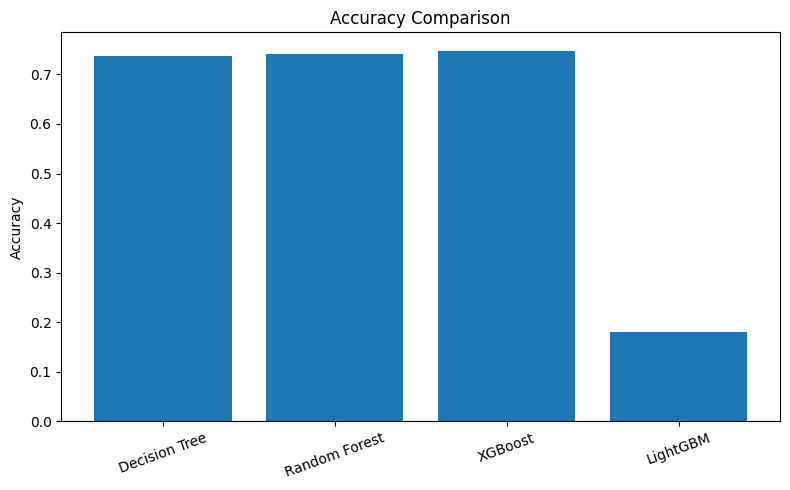

In [43]:
plt.figure(figsize=(8,5))

plt.bar(

    results_df["Model"],

    results_df["Accuracy"]

)

plt.ylabel("Accuracy")

plt.title("Accuracy Comparison")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(

    os.path.join(

        FIGURE_PATH,

        "Accuracy_Comparison.png"

    ),

    dpi=300

)

plt.show()

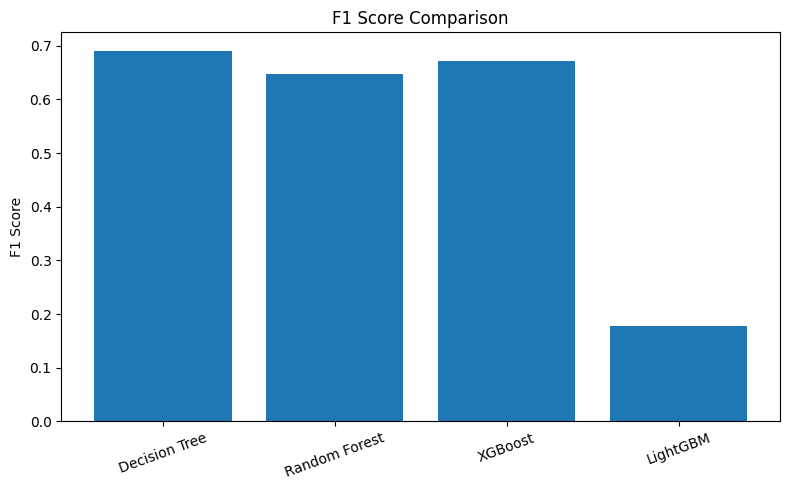

In [44]:
plt.figure(figsize=(8,5))

plt.bar(

    results_df["Model"],

    results_df["F1 Score"]

)

plt.ylabel("F1 Score")

plt.title("F1 Score Comparison")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(

    os.path.join(

        FIGURE_PATH,

        "F1_Comparison.png"

    ),

    dpi=300

)

plt.show()

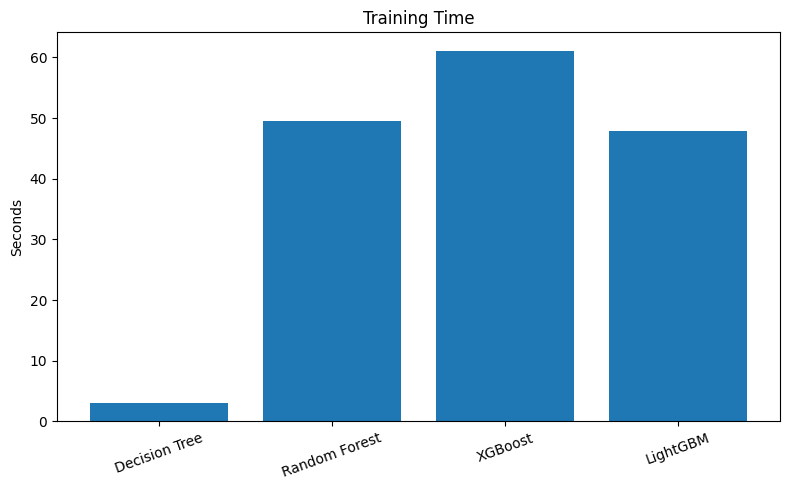

In [45]:
plt.figure(figsize=(8,5))

plt.bar(

    results_df["Model"],

    results_df["Training Time (s)"]

)

plt.ylabel("Seconds")

plt.title("Training Time")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(

    os.path.join(

        FIGURE_PATH,

        "Training_Time.png"

    ),

    dpi=300

)

plt.show()

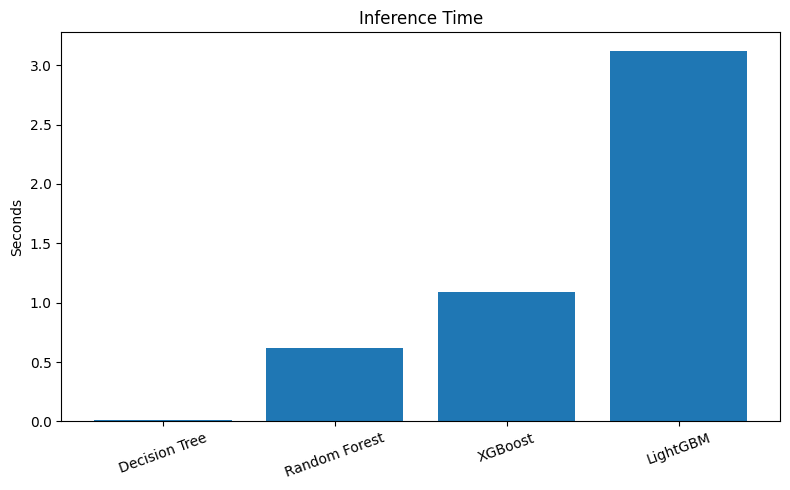

In [46]:
plt.figure(figsize=(8,5))

plt.bar(

    results_df["Model"],

    results_df["Inference Time (s)"]

)

plt.ylabel("Seconds")

plt.title("Inference Time")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(

    os.path.join(

        FIGURE_PATH,

        "Inference_Time.png"

    ),

    dpi=300

)

plt.show()

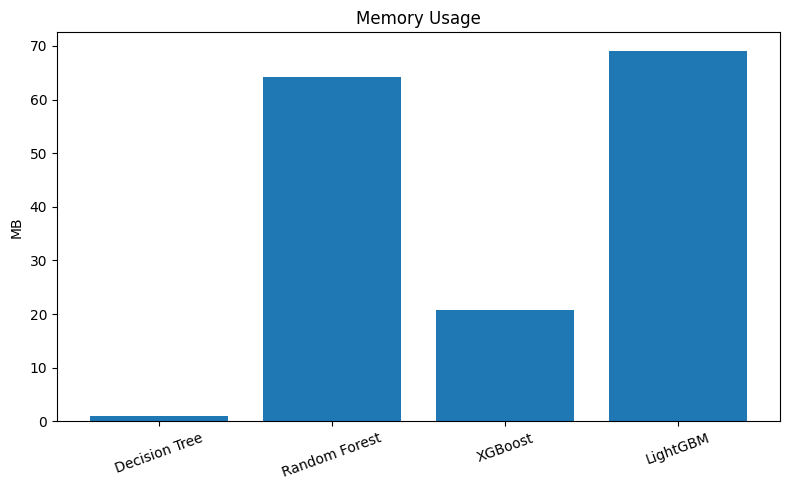

In [47]:
plt.figure(figsize=(8,5))

plt.bar(

    results_df["Model"],

    results_df["Memory Usage (MB)"]

)

plt.ylabel("MB")

plt.title("Memory Usage")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(

    os.path.join(

        FIGURE_PATH,

        "Memory_Usage.png"

    ),

    dpi=300

)

plt.show()

In [48]:
print("="*80)

print("RQ1 COMPLETED")

print("="*80)

display(results_df)

RQ1 COMPLETED


,Model,Accuracy,Precision,Recall,F1 Score,False Positive Rate,Training Time (s),Inference Time (s),Memory Usage (MB)
0,Decision Tree,0.737706,0.846087,0.737706,0.690444,0.041812,3.036906,0.009091,0.972656
1,Random Forest,0.740687,0.812645,0.740687,0.646613,0.050601,49.563239,0.616357,64.222656
2,XGBoost,0.747572,0.806124,0.747572,0.670882,0.045764,61.081589,1.091423,20.691406
3,LightGBM,0.180181,0.234601,0.180181,0.176909,0.130949,47.913905,3.121886,69.085938


**RQ2**

In [49]:
import numpy as np
import pandas as pd

from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import RFE

from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt

In [50]:
feature_names = train_df.drop(
    columns=["Label","Target"]
).columns

X_train_df = pd.DataFrame(
    X_train,
    columns=feature_names
)

X_test_df = pd.DataFrame(
    X_test,
    columns=feature_names
)

Stage 1 — Filter Method

In [51]:
mi_scores = mutual_info_classif(

    X_train_df,

    y_train,

    random_state=42

)

mi = pd.DataFrame({

    "Feature":feature_names,

    "Score":mi_scores

})

mi = mi.sort_values(

    by="Score",

    ascending=False

)

mi.head(20)

,Feature,Score
52,Avg Packet Size,1.214918
62,Subflow Fwd Bytes,1.139678
4,Fwd Packets Length Total,1.139459
14,Flow Bytes/s,1.100170
40,Packet Length Mean,1.085451
8,Fwd Packet Length Mean,1.081067
53,Avg Fwd Segment Size,1.080934
39,Packet Length Max,1.056287
38,Packet Length Min,1.045893
6,Fwd Packet Length Max,1.040857


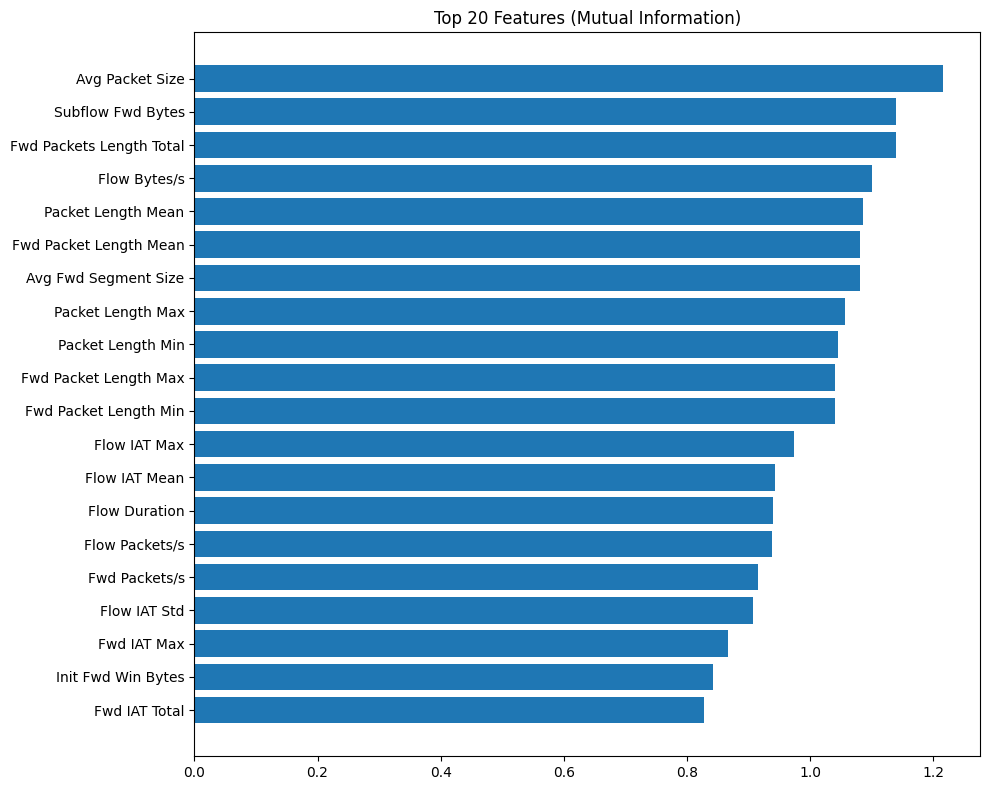

In [52]:
plt.figure(figsize=(10,8))

plt.barh(

    mi.head(20)["Feature"],

    mi.head(20)["Score"]

)

plt.gca().invert_yaxis()

plt.title("Top 20 Features (Mutual Information)")

plt.tight_layout()

plt.savefig(

    os.path.join(

        FIGURE_PATH,

        "RQ2_Filter_Features.png"

    ),

    dpi=300

)

plt.show()

In [53]:
FILTER_FEATURES = mi.head(40)["Feature"].tolist()

print("Selected Features:",len(FILTER_FEATURES))

Selected Features: 40


Stage 2 — Wrapper Method

In [54]:
wrapper = RandomForestClassifier(

    n_estimators=100,

    random_state=42,

    n_jobs=-1

)

In [55]:
rfe = RFE(

    estimator=wrapper,

    n_features_to_select=25,

    step=2

)

rfe.fit(

    X_train_df[FILTER_FEATURES],

    y_train

)

RFE(estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
    n_features_to_select=25, step=2)

In [56]:
WRAPPER_FEATURES = list(

    np.array(FILTER_FEATURES)[

        rfe.support_

    ]

)

print(WRAPPER_FEATURES)

print()

print("Wrapper Features:",len(WRAPPER_FEATURES))

[np.str_('Avg Packet Size'), np.str_('Subflow Fwd Bytes'), np.str_('Fwd Packets Length Total'), np.str_('Flow Bytes/s'), np.str_('Packet Length Mean'), np.str_('Fwd Packet Length Mean'), np.str_('Avg Fwd Segment Size'), np.str_('Packet Length Max'), np.str_('Packet Length Min'), np.str_('Fwd Packet Length Max'), np.str_('Fwd Packet Length Min'), np.str_('Flow IAT Mean'), np.str_('Flow Packets/s'), np.str_('Fwd IAT Max'), np.str_('Init Fwd Win Bytes'), np.str_('Fwd IAT Mean'), np.str_('Packet Length Std'), np.str_('Bwd Packets/s'), np.str_('Packet Length Variance'), np.str_('Fwd Act Data Packets'), np.str_('Init Bwd Win Bytes'), np.str_('ACK Flag Count'), np.str_('Bwd Header Length'), np.str_('Fwd Packet Length Std'), np.str_('Fwd Seg Size Min')]

Wrapper Features: 25


Stage 3 — Embedded Method

In [57]:
rf = RandomForestClassifier(

    n_estimators=300,

    random_state=42,

    n_jobs=-1

)

rf.fit(

    X_train_df[WRAPPER_FEATURES],

    y_train

)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

In [58]:
importance = pd.DataFrame({

    "Feature":WRAPPER_FEATURES,

    "Importance":rf.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance

,Feature,Importance
0,Avg Packet Size,0.137705
8,Packet Length Min,0.093717
21,ACK Flag Count,0.088869
14,Init Fwd Win Bytes,0.082480
10,Fwd Packet Length Min,0.080354
4,Packet Length Mean,0.071705
5,Fwd Packet Length Mean,0.058537
7,Packet Length Max,0.053649
6,Avg Fwd Segment Size,0.046894
11,Flow IAT Mean,0.042771


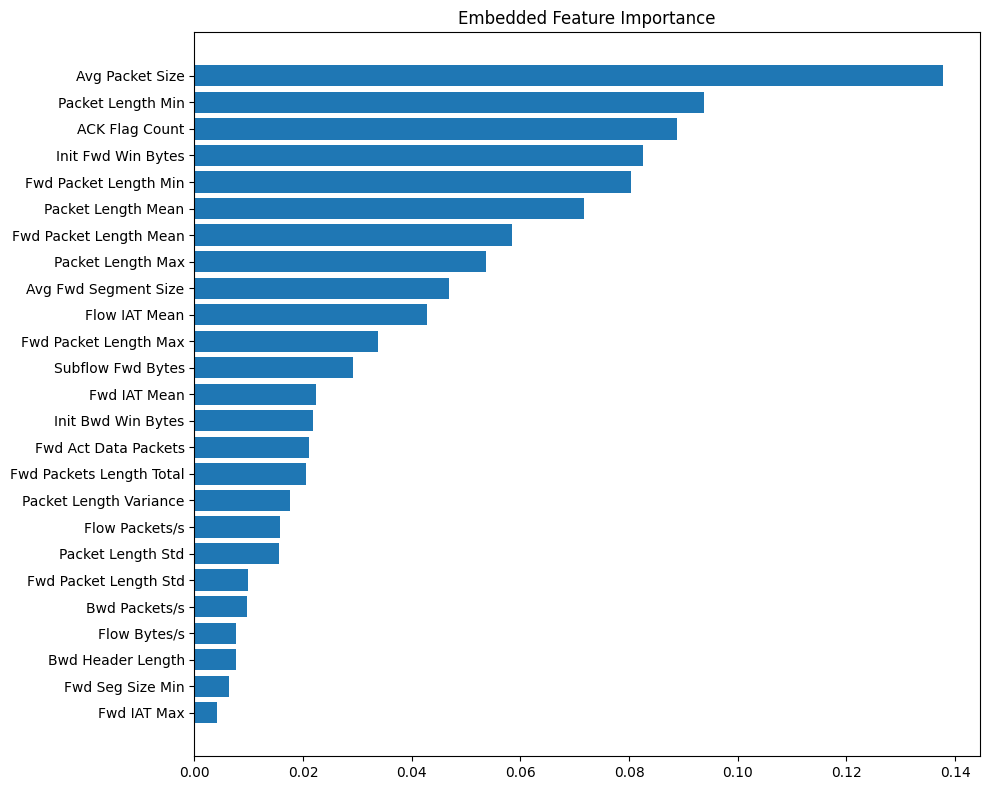

In [59]:
plt.figure(figsize=(10,8))

plt.barh(

    importance["Feature"],

    importance["Importance"]

)

plt.gca().invert_yaxis()

plt.title("Embedded Feature Importance")

plt.tight_layout()

plt.savefig(

    os.path.join(

        FIGURE_PATH,

        "RQ2_Embedded_Features.png"

    ),

    dpi=300

)

plt.show()

In [60]:
FINAL_FEATURES = importance.head(15)["Feature"].tolist()

print()

print(FINAL_FEATURES)

print()

print("Final Features:",len(FINAL_FEATURES))


[np.str_('Avg Packet Size'), np.str_('Packet Length Min'), np.str_('ACK Flag Count'), np.str_('Init Fwd Win Bytes'), np.str_('Fwd Packet Length Min'), np.str_('Packet Length Mean'), np.str_('Fwd Packet Length Mean'), np.str_('Packet Length Max'), np.str_('Avg Fwd Segment Size'), np.str_('Flow IAT Mean'), np.str_('Fwd Packet Length Max'), np.str_('Subflow Fwd Bytes'), np.str_('Fwd IAT Mean'), np.str_('Init Bwd Win Bytes'), np.str_('Fwd Act Data Packets')]

Final Features: 15


In [61]:
selected_features = pd.DataFrame({

    "Feature":FINAL_FEATURES

})

selected_features.to_csv(

    os.path.join(

        TABLE_PATH,

        "RQ2_Selected_Features.csv"

    ),

    index=False

)

In [62]:
X_train_selected = X_train_df[FINAL_FEATURES]

X_test_selected = X_test_df[FINAL_FEATURES]

print(X_train_selected.shape)

print(X_test_selected.shape)

(120065, 15)
(38922, 15)


In [63]:
import time
import psutil
import joblib

import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [64]:
models_fs = {

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ),

    "XGBoost":
        XGBClassifier(
            objective="multi:softprob",
            eval_metric="mlogloss",
            tree_method="hist",
            random_state=42,
            n_estimators=200
        ),

    "LightGBM":
        LGBMClassifier(
            random_state=42,
            n_estimators=200
        )

}

In [65]:
def calculate_fpr(cm):

    FP = cm.sum(axis=0) - np.diag(cm)

    FN = cm.sum(axis=1) - np.diag(cm)

    TP = np.diag(cm)

    TN = cm.sum() - (FP + FN + TP)

    return np.mean(FP / (FP + TN + 1e-10))

In [66]:
def evaluate_selected_features(model, model_name):

    process = psutil.Process()

    memory_before = process.memory_info().rss

    start_train = time.time()

    model.fit(
        X_train_selected,
        y_train
    )

    training_time = time.time() - start_train

    memory_after = process.memory_info().rss

    memory_usage = (
        memory_after - memory_before
    ) / (1024**2)

    start_test = time.time()

    prediction = model.predict(
        X_test_selected
    )

    inference_time = time.time() - start_test

    accuracy = accuracy_score(
        y_test,
        prediction
    )

    precision = precision_score(
        y_test,
        prediction,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        prediction,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        prediction,
        average="weighted",
        zero_division=0
    )

    cm = confusion_matrix(
        y_test,
        prediction
    )

    fpr = calculate_fpr(cm)

    print("="*70)
    print(model_name)
    print("="*70)

    print(classification_report(
        y_test,
        prediction,
        target_names=encoder.classes_
    ))

    return {

        "Model": model_name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1": f1,

        "False Positive Rate": fpr,

        "Training Time": training_time,

        "Inference Time": inference_time,

        "Memory Usage": memory_usage,

        "Confusion Matrix": cm,

        "Model Object": model

    }

In [67]:
rq2_results = []

for name, model in models_fs.items():

    result = evaluate_selected_features(
        model,
        name
    )

    rq2_results.append(result)

Decision Tree
               precision    recall  f1-score   support

       Benign       1.00      0.99      0.99     10847
   DrDoS_LDAP       0.16      0.97      0.27      1440
  DrDoS_MSSQL       0.94      0.96      0.95      6212
DrDoS_NetBIOS       0.98      0.69      0.81       598
    DrDoS_UDP       0.82      0.98      0.90     10420
          Syn       0.00      0.00      0.00       533
      UDP-lag       0.81      0.00      0.00      8872

     accuracy                           0.74     38922
    macro avg       0.67      0.66      0.56     38922
 weighted avg       0.85      0.74      0.69     38922

Random Forest
               precision    recall  f1-score   support

       Benign       0.60      1.00      0.75     10847
   DrDoS_LDAP       0.85      0.98      0.91      1440
  DrDoS_MSSQL       0.94      0.96      0.95      6212
DrDoS_NetBIOS       1.00      0.69      0.82       598
    DrDoS_UDP       0.82      0.98      0.90     10420
          Syn       0.00      0.0

In [68]:
for result in rq2_results:

    joblib.dump(

        result["Model Object"],

        os.path.join(

            MODEL_PATH,

            f"RQ2_{result['Model'].replace(' ','_')}.pkl"

        )

    )

In [69]:
for result in rq2_results:

    fig, ax = plt.subplots(figsize=(8,8))

    disp = ConfusionMatrixDisplay(

        confusion_matrix=result["Confusion Matrix"],

        display_labels=encoder.classes_

    )

    disp.plot(

        cmap="Blues",

        xticks_rotation=45,

        ax=ax

    )

    plt.title(result["Model"])

    plt.tight_layout()

    plt.savefig(

        os.path.join(

            FIGURE_PATH,

            f"RQ2_{result['Model'].replace(' ','_')}_CM.png"

        ),

        dpi=300

    )

    plt.close()

In [70]:
rq2_df = pd.DataFrame({

    "Model":[r["Model"] for r in rq2_results],

    "Accuracy":[r["Accuracy"] for r in rq2_results],

    "Precision":[r["Precision"] for r in rq2_results],

    "Recall":[r["Recall"] for r in rq2_results],

    "F1 Score":[r["F1"] for r in rq2_results],

    "False Positive Rate":[r["False Positive Rate"] for r in rq2_results],

    "Training Time (s)":[r["Training Time"] for r in rq2_results],

    "Inference Time (s)":[r["Inference Time"] for r in rq2_results],

    "Memory Usage (MB)":[r["Memory Usage"] for r in rq2_results]

})

rq2_df

,Model,Accuracy,Precision,Recall,F1 Score,False Positive Rate,Training Time (s),Inference Time (s),Memory Usage (MB)
0,Decision Tree,0.738734,0.854791,0.738734,0.691561,0.041621,0.571822,0.005934,0.000000
1,Random Forest,0.741098,0.813101,0.741098,0.647323,0.050437,18.972951,0.847892,37.683594
2,XGBoost,0.739171,0.812438,0.739171,0.645863,0.050683,21.745811,1.031423,0.078125
3,LightGBM,0.573557,0.507904,0.573557,0.512874,0.077464,13.518450,1.526259,0.007812


In [71]:
rq2_df.to_csv(

    os.path.join(

        TABLE_PATH,

        "RQ2_Model_Comparison.csv"

    ),

    index=False

)

In [72]:
comparison = results_df.merge(

    rq2_df,

    on="Model",

    suffixes=(

        "_Full",

        "_Selected"

    )

)

comparison

,Model,Accuracy_Full,Precision_Full,Recall_Full,F1 Score_Full,False Positive Rate_Full,Training Time (s)_Full,Inference Time (s)_Full,Memory Usage (MB)_Full,Accuracy_Selected,Precision_Selected,Recall_Selected,F1 Score_Selected,False Positive Rate_Selected,Training Time (s)_Selected,Inference Time (s)_Selected,Memory Usage (MB)_Selected
0,Decision Tree,0.737706,0.846087,0.737706,0.690444,0.041812,3.036906,0.009091,0.972656,0.738734,0.854791,0.738734,0.691561,0.041621,0.571822,0.005934,0.000000
1,Random Forest,0.740687,0.812645,0.740687,0.646613,0.050601,49.563239,0.616357,64.222656,0.741098,0.813101,0.741098,0.647323,0.050437,18.972951,0.847892,37.683594
2,XGBoost,0.747572,0.806124,0.747572,0.670882,0.045764,61.081589,1.091423,20.691406,0.739171,0.812438,0.739171,0.645863,0.050683,21.745811,1.031423,0.078125
3,LightGBM,0.180181,0.234601,0.180181,0.176909,0.130949,47.913905,3.121886,69.085938,0.573557,0.507904,0.573557,0.512874,0.077464,13.518450,1.526259,0.007812


In [73]:
comparison.to_csv(

    os.path.join(

        TABLE_PATH,

        "RQ1_vs_RQ2.csv"

    ),

    index=False

)

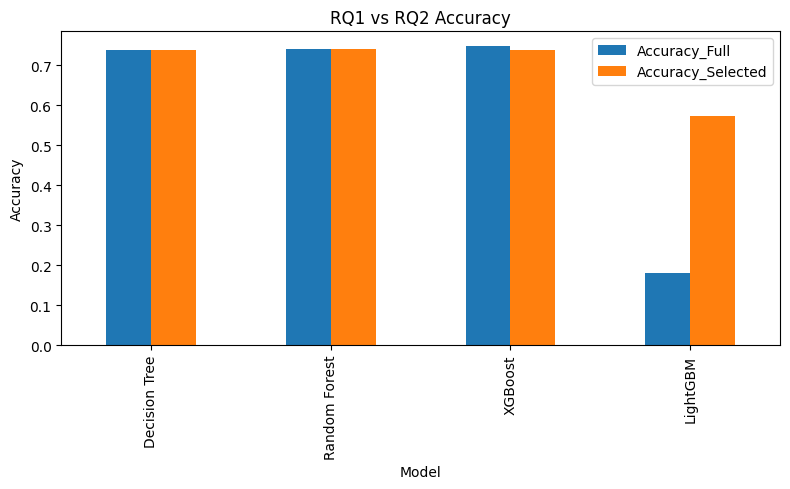

In [74]:
comparison.plot(

    x="Model",

    y=[

        "Accuracy_Full",

        "Accuracy_Selected"

    ],

    kind="bar",

    figsize=(8,5)

)

plt.ylabel("Accuracy")

plt.title("RQ1 vs RQ2 Accuracy")

plt.tight_layout()

plt.savefig(

    os.path.join(

        FIGURE_PATH,

        "RQ1_vs_RQ2_Accuracy.png"

    ),

    dpi=300

)

plt.show()

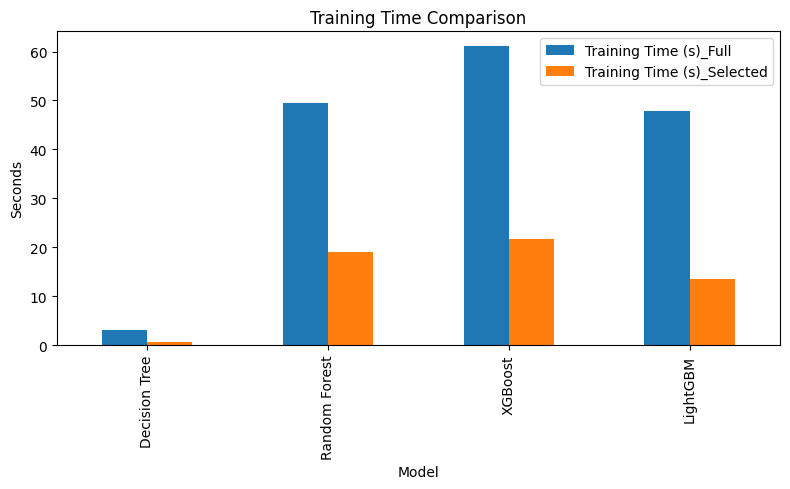

In [75]:
comparison.plot(

    x="Model",

    y=[

        "Training Time (s)_Full",

        "Training Time (s)_Selected"

    ],

    kind="bar",

    figsize=(8,5)

)

plt.ylabel("Seconds")

plt.title("Training Time Comparison")

plt.tight_layout()

plt.savefig(

    os.path.join(

        FIGURE_PATH,

        "RQ1_vs_RQ2_TrainingTime.png"

    ),

    dpi=300

)

plt.show()

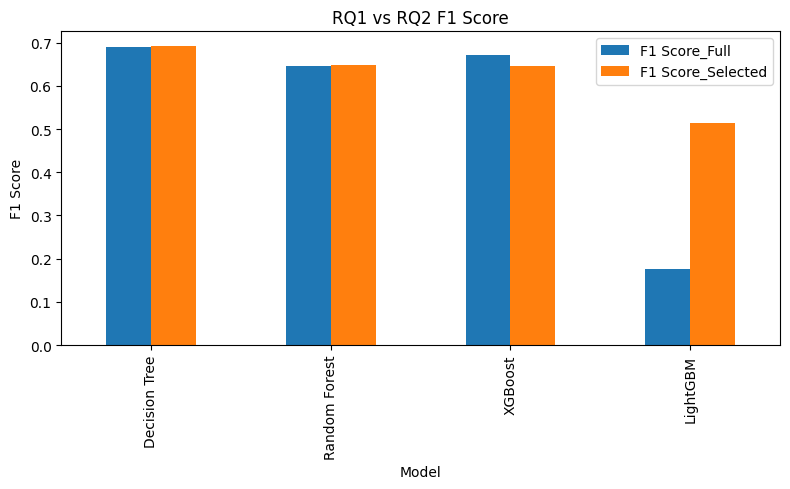

In [76]:
comparison.plot(

    x="Model",

    y=[

        "F1 Score_Full",

        "F1 Score_Selected"

    ],

    kind="bar",

    figsize=(8,5)

)

plt.ylabel("F1 Score")

plt.title("RQ1 vs RQ2 F1 Score")

plt.tight_layout()

plt.savefig(

    os.path.join(

        FIGURE_PATH,

        "RQ1_vs_RQ2_F1.png"

    ),

    dpi=300

)

plt.show()

In [77]:
print("="*80)
print("RQ2 COMPLETED")
print("="*80)

display(rq2_df)

print("\nComparison with RQ1\n")

display(comparison)

RQ2 COMPLETED


,Model,Accuracy,Precision,Recall,F1 Score,False Positive Rate,Training Time (s),Inference Time (s),Memory Usage (MB)
0,Decision Tree,0.738734,0.854791,0.738734,0.691561,0.041621,0.571822,0.005934,0.000000
1,Random Forest,0.741098,0.813101,0.741098,0.647323,0.050437,18.972951,0.847892,37.683594
2,XGBoost,0.739171,0.812438,0.739171,0.645863,0.050683,21.745811,1.031423,0.078125
3,LightGBM,0.573557,0.507904,0.573557,0.512874,0.077464,13.518450,1.526259,0.007812



Comparison with RQ1



,Model,Accuracy_Full,Precision_Full,Recall_Full,F1 Score_Full,False Positive Rate_Full,Training Time (s)_Full,Inference Time (s)_Full,Memory Usage (MB)_Full,Accuracy_Selected,Precision_Selected,Recall_Selected,F1 Score_Selected,False Positive Rate_Selected,Training Time (s)_Selected,Inference Time (s)_Selected,Memory Usage (MB)_Selected
0,Decision Tree,0.737706,0.846087,0.737706,0.690444,0.041812,3.036906,0.009091,0.972656,0.738734,0.854791,0.738734,0.691561,0.041621,0.571822,0.005934,0.000000
1,Random Forest,0.740687,0.812645,0.740687,0.646613,0.050601,49.563239,0.616357,64.222656,0.741098,0.813101,0.741098,0.647323,0.050437,18.972951,0.847892,37.683594
2,XGBoost,0.747572,0.806124,0.747572,0.670882,0.045764,61.081589,1.091423,20.691406,0.739171,0.812438,0.739171,0.645863,0.050683,21.745811,1.031423,0.078125
3,LightGBM,0.180181,0.234601,0.180181,0.176909,0.130949,47.913905,3.121886,69.085938,0.573557,0.507904,0.573557,0.512874,0.077464,13.518450,1.526259,0.007812


**RQ3**

In [78]:
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [79]:
train_binary = train_df.copy()

train_binary["Binary"] = train_binary["Label"].apply(
    lambda x: 0 if x == "Benign" else 1
)

In [80]:
dns_df = pd.read_parquet(

    os.path.join(
        DATA_PATH,
        "DNS-testing.parquet"
    )

)

In [81]:
dns_df.replace(

    [np.inf, -np.inf],

    np.nan,

    inplace=True

)

dns_df.dropna(inplace=True)

dns_df.drop_duplicates(inplace=True)

In [82]:
dns_df["Binary"] = dns_df["Label"].apply(

    lambda x: 0 if x == "Benign" else 1

)

In [83]:
X_train_binary = train_binary.drop(

    columns=[
        "Label",
        "Target",
        "Binary"
    ]

)

y_train_binary = train_binary["Binary"]

In [84]:
X_dns = dns_df.drop(

    columns=[
        "Label",
        "Binary"
    ]

)

y_dns = dns_df["Binary"]

In [85]:
X_train_binary = scaler.fit_transform(
    X_train_binary
)

X_dns = scaler.transform(
    X_dns
)

In [86]:
binary_dt = DecisionTreeClassifier(

    random_state=42

)

binary_dt.fit(

    X_train_binary,

    y_train_binary

)

DecisionTreeClassifier(random_state=42)

In [87]:
dns_prediction = binary_dt.predict(
    X_dns
)

In [88]:
accuracy = accuracy_score(
    y_dns,
    dns_prediction
)

precision = precision_score(
    y_dns,
    dns_prediction
)

recall = recall_score(
    y_dns,
    dns_prediction
)

f1 = f1_score(
    y_dns,
    dns_prediction
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.9554
Precision: 0.9864
Recall   : 0.9313
F1 Score : 0.9581


In [89]:
print(

    classification_report(

        y_dns,

        dns_prediction,

        target_names=[

            "Benign",

            "Attack"

        ]

    )

)

              precision    recall  f1-score   support

      Benign       0.92      0.98      0.95      3034
      Attack       0.99      0.93      0.96      3669

    accuracy                           0.96      6703
   macro avg       0.95      0.96      0.96      6703
weighted avg       0.96      0.96      0.96      6703



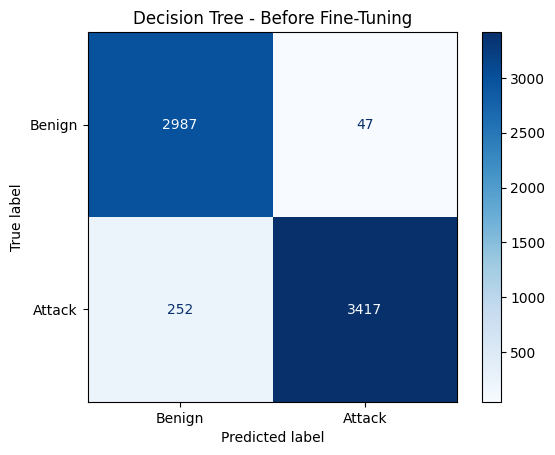

In [90]:
cm = confusion_matrix(

    y_dns,

    dns_prediction

)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=[

        "Benign",

        "Attack"

    ]

)

disp.plot(cmap="Blues")

plt.title(

    "Decision Tree - Before Fine-Tuning"

)

plt.show()

In [91]:
rq3_before = pd.DataFrame({

    "Stage":["Before Fine-Tuning"],

    "Model":["Decision Tree"],

    "Accuracy":[accuracy],

    "Precision":[precision],

    "Recall":[recall],

    "F1 Score":[f1]

})

rq3_before

,Stage,Model,Accuracy,Precision,Recall,F1 Score
0,Before Fine-Tuning,Decision Tree,0.955393,0.986432,0.931316,0.958082


In [92]:
rq3_before.to_csv(

    os.path.join(

        TABLE_PATH,

        "RQ3_Before_Fine_Tuning.csv"

    ),

    index=False

)

**(10% Fine-Tuning)**

In [93]:
from sklearn.model_selection import train_test_split

dns_finetune, dns_test = train_test_split(
    dns_df,
    train_size=0.10,
    random_state=42,
    stratify=dns_df["Binary"]
)

print("Fine-tuning dataset :", dns_finetune.shape)
print("Testing dataset     :", dns_test.shape)

print("\nFine-tuning label distribution")
print(dns_finetune["Binary"].value_counts())

print("\nTesting label distribution")
print(dns_test["Binary"].value_counts())

Fine-tuning dataset : (670, 79)
Testing dataset     : (6033, 79)

Fine-tuning label distribution
Binary
1    367
0    303
Name: count, dtype: int64

Testing label distribution
Binary
1    3302
0    2731
Name: count, dtype: int64


In [94]:
X_dns_finetune = dns_finetune.drop(
    columns=["Label", "Binary"]
)

y_dns_finetune = dns_finetune["Binary"]

X_dns_test = dns_test.drop(
    columns=["Label", "Binary"]
)

y_dns_test = dns_test["Binary"]

In [95]:
X_dns_finetune = scaler.transform(X_dns_finetune)

X_dns_test = scaler.transform(X_dns_test)

In [96]:
import numpy as np

X_train_10 = np.vstack([
    X_train_binary,
    X_dns_finetune
])

y_train_10 = np.concatenate([
    y_train_binary,
    y_dns_finetune
])

print("Combined Training Shape:", X_train_10.shape)

Combined Training Shape: (120735, 77)


In [97]:
decision_tree_10 = DecisionTreeClassifier(
    random_state=42
)

decision_tree_10.fit(
    X_train_10,
    y_train_10
)

DecisionTreeClassifier(random_state=42)

In [98]:
prediction_10 = decision_tree_10.predict(
    X_dns_test
)

In [99]:
accuracy_10 = accuracy_score(
    y_dns_test,
    prediction_10
)

precision_10 = precision_score(
    y_dns_test,
    prediction_10
)

recall_10 = recall_score(
    y_dns_test,
    prediction_10
)

f1_10 = f1_score(
    y_dns_test,
    prediction_10
)

print(f"Accuracy : {accuracy_10:.4f}")
print(f"Precision: {precision_10:.4f}")
print(f"Recall   : {recall_10:.4f}")
print(f"F1 Score : {f1_10:.4f}")

Accuracy : 0.9733
Precision: 0.9956
Recall   : 0.9555
F1 Score : 0.9751


In [100]:
print(
    classification_report(
        y_dns_test,
        prediction_10,
        target_names=[
            "Benign",
            "Attack"
        ]
    )
)

              precision    recall  f1-score   support

      Benign       0.95      0.99      0.97      2731
      Attack       1.00      0.96      0.98      3302

    accuracy                           0.97      6033
   macro avg       0.97      0.98      0.97      6033
weighted avg       0.97      0.97      0.97      6033



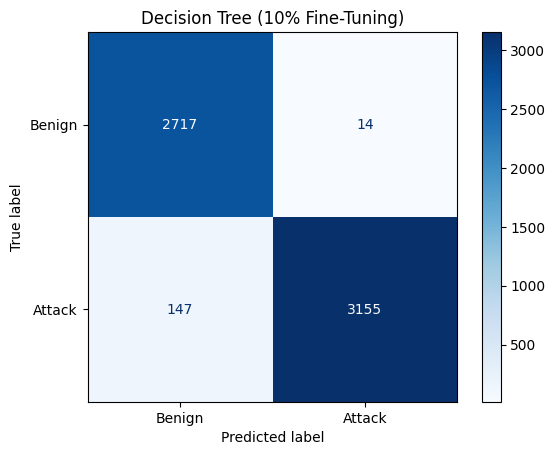

In [101]:
cm_10 = confusion_matrix(
    y_dns_test,
    prediction_10
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_10,
    display_labels=[
        "Benign",
        "Attack"
    ]
)

disp.plot(cmap="Blues")

plt.title("Decision Tree (10% Fine-Tuning)")

plt.show()

In [102]:
rq3_10 = pd.DataFrame({

    "Stage": ["10% Fine-Tuning"],

    "Model": ["Decision Tree"],

    "Accuracy": [accuracy_10],

    "Precision": [precision_10],

    "Recall": [recall_10],

    "F1 Score": [f1_10]

})

rq3_10

,Stage,Model,Accuracy,Precision,Recall,F1 Score
0,10% Fine-Tuning,Decision Tree,0.973313,0.995582,0.955482,0.97512


In [103]:
rq3_10.to_csv(

    os.path.join(
        TABLE_PATH,
        "RQ3_10_Percent_Fine_Tuning.csv"
    ),

    index=False

)

**(20% Fine-Tuning)**

In [104]:
from sklearn.model_selection import train_test_split

dns_finetune_20, dns_test_20 = train_test_split(
    dns_df,
    train_size=0.20,
    random_state=42,
    stratify=dns_df["Binary"]
)

print("20% Fine-Tuning Dataset :", dns_finetune_20.shape)
print("80% Testing Dataset     :", dns_test_20.shape)

print("\nFine-Tuning Distribution")
print(dns_finetune_20["Binary"].value_counts())

print("\nTesting Distribution")
print(dns_test_20["Binary"].value_counts())

20% Fine-Tuning Dataset : (1340, 79)
80% Testing Dataset     : (5363, 79)

Fine-Tuning Distribution
Binary
1    733
0    607
Name: count, dtype: int64

Testing Distribution
Binary
1    2936
0    2427
Name: count, dtype: int64


In [105]:
X_dns_finetune_20 = dns_finetune_20.drop(
    columns=["Label", "Binary"]
)

y_dns_finetune_20 = dns_finetune_20["Binary"]

X_dns_test_20 = dns_test_20.drop(
    columns=["Label", "Binary"]
)

y_dns_test_20 = dns_test_20["Binary"]

In [106]:
X_dns_finetune_20 = scaler.transform(X_dns_finetune_20)

X_dns_test_20 = scaler.transform(X_dns_test_20)

In [107]:
X_train_20 = np.vstack([
    X_train_binary,
    X_dns_finetune_20
])

y_train_20 = np.concatenate([
    y_train_binary,
    y_dns_finetune_20
])

print(X_train_20.shape)

(121405, 77)


In [108]:
decision_tree_20 = DecisionTreeClassifier(
    random_state=42
)

decision_tree_20.fit(
    X_train_20,
    y_train_20
)

DecisionTreeClassifier(random_state=42)

In [109]:
prediction_20 = decision_tree_20.predict(
    X_dns_test_20
)

In [110]:
accuracy_20 = accuracy_score(
    y_dns_test_20,
    prediction_20
)

precision_20 = precision_score(
    y_dns_test_20,
    prediction_20
)

recall_20 = recall_score(
    y_dns_test_20,
    prediction_20
)

f1_20 = f1_score(
    y_dns_test_20,
    prediction_20
)

print(f"Accuracy : {accuracy_20:.4f}")
print(f"Precision: {precision_20:.4f}")
print(f"Recall   : {recall_20:.4f}")
print(f"F1 Score : {f1_20:.4f}")

Accuracy : 0.9838
Precision: 0.9976
Recall   : 0.9728
F1 Score : 0.9850


In [111]:
print(
    classification_report(
        y_dns_test_20,
        prediction_20,
        target_names=[
            "Benign",
            "Attack"
        ]
    )
)

              precision    recall  f1-score   support

      Benign       0.97      1.00      0.98      2427
      Attack       1.00      0.97      0.98      2936

    accuracy                           0.98      5363
   macro avg       0.98      0.98      0.98      5363
weighted avg       0.98      0.98      0.98      5363



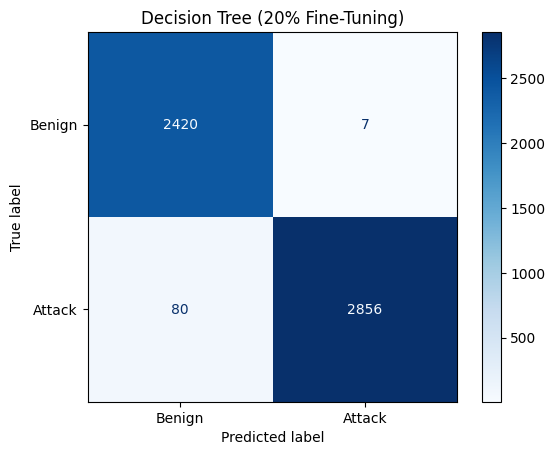

In [112]:
cm_20 = confusion_matrix(
    y_dns_test_20,
    prediction_20
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_20,
    display_labels=[
        "Benign",
        "Attack"
    ]
)

disp.plot(cmap="Blues")

plt.title("Decision Tree (20% Fine-Tuning)")

plt.show()

In [113]:
rq3_20 = pd.DataFrame({

    "Stage":["20% Fine-Tuning"],

    "Model":["Decision Tree"],

    "Accuracy":[accuracy_20],

    "Precision":[precision_20],

    "Recall":[recall_20],

    "F1 Score":[f1_20]

})

rq3_20

,Stage,Model,Accuracy,Precision,Recall,F1 Score
0,20% Fine-Tuning,Decision Tree,0.983778,0.997555,0.972752,0.984997


In [114]:
rq3_20.to_csv(

    os.path.join(

        TABLE_PATH,

        "RQ3_20_Percent_Fine_Tuning.csv"

    ),

    index=False

)

Final Comparison

In [115]:
rq3_final = pd.concat([
    rq3_before,
    rq3_10,
    rq3_20
], ignore_index=True)

rq3_final

,Stage,Model,Accuracy,Precision,Recall,F1 Score
0,Before Fine-Tuning,Decision Tree,0.955393,0.986432,0.931316,0.958082
1,10% Fine-Tuning,Decision Tree,0.973313,0.995582,0.955482,0.975120
2,20% Fine-Tuning,Decision Tree,0.983778,0.997555,0.972752,0.984997


In [116]:
rq3_final.to_csv(
    os.path.join(
        TABLE_PATH,
        "RQ3_Final_Comparison.csv"
    ),
    index=False
)

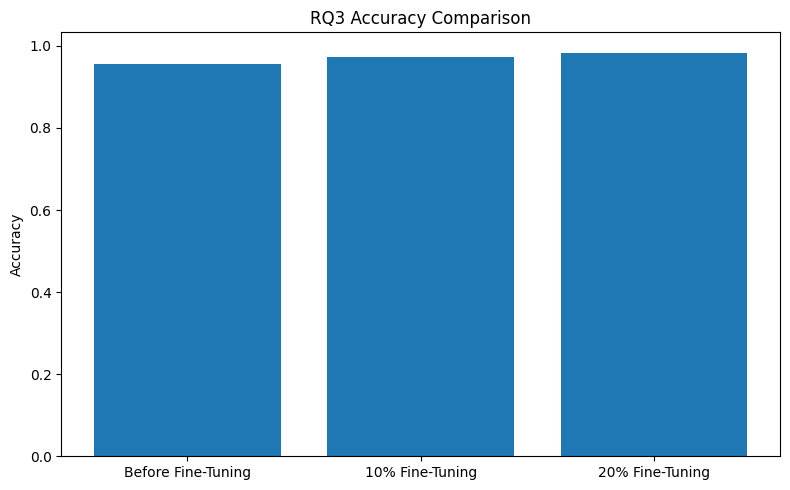

In [117]:
plt.figure(figsize=(8,5))

plt.bar(
    rq3_final["Stage"],
    rq3_final["Accuracy"]
)

plt.ylabel("Accuracy")
plt.title("RQ3 Accuracy Comparison")

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_PATH,
        "RQ3_Accuracy.png"
    ),
    dpi=300
)

plt.show()

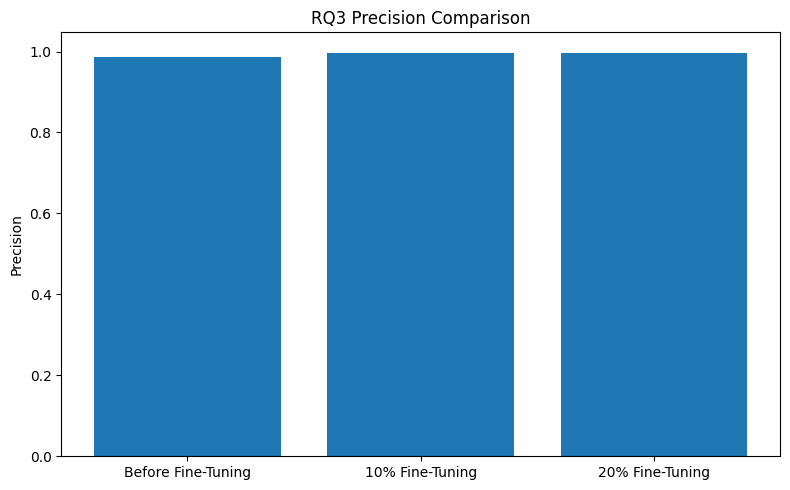

In [118]:
plt.figure(figsize=(8,5))

plt.bar(
    rq3_final["Stage"],
    rq3_final["Precision"]
)

plt.ylabel("Precision")
plt.title("RQ3 Precision Comparison")

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_PATH,
        "RQ3_Precision.png"
    ),
    dpi=300
)

plt.show()

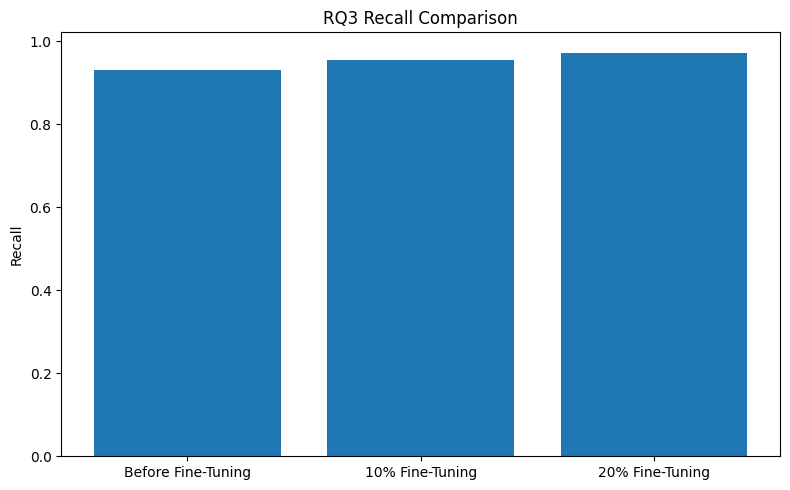

In [119]:
plt.figure(figsize=(8,5))

plt.bar(
    rq3_final["Stage"],
    rq3_final["Recall"]
)

plt.ylabel("Recall")
plt.title("RQ3 Recall Comparison")

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_PATH,
        "RQ3_Recall.png"
    ),
    dpi=300
)

plt.show()

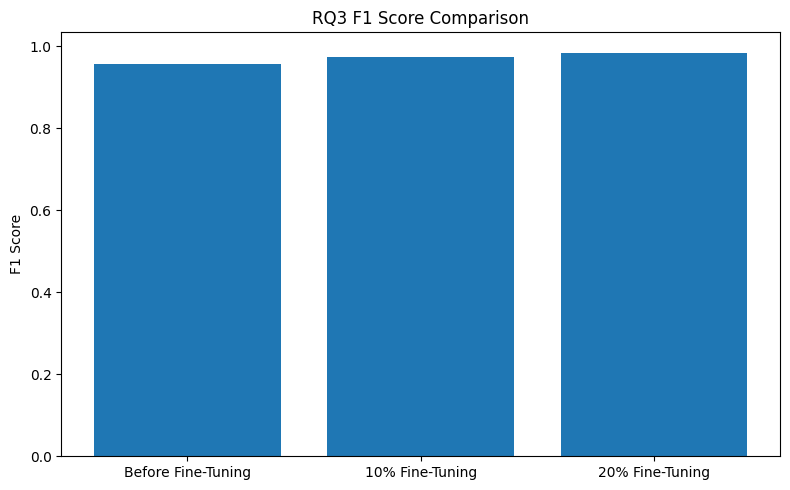

In [120]:
plt.figure(figsize=(8,5))

plt.bar(
    rq3_final["Stage"],
    rq3_final["F1 Score"]
)

plt.ylabel("F1 Score")
plt.title("RQ3 F1 Score Comparison")

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_PATH,
        "RQ3_F1.png"
    ),
    dpi=300
)

plt.show()

In [121]:
print("="*80)
print("RQ3 COMPLETED")
print("="*80)

display(rq3_final)

RQ3 COMPLETED


,Stage,Model,Accuracy,Precision,Recall,F1 Score
0,Before Fine-Tuning,Decision Tree,0.955393,0.986432,0.931316,0.958082
1,10% Fine-Tuning,Decision Tree,0.973313,0.995582,0.955482,0.975120
2,20% Fine-Tuning,Decision Tree,0.983778,0.997555,0.972752,0.984997
